### Team of Agents with a supervisor

In [2]:
from langchain_ollama.chat_models import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field


class TransferNewsGrader(BaseModel):
    """Binary score for relevance check on football transfer news."""

    binary_score: str = Field(
        description="The article is about football transfers, 'yes' or 'no'"
    )

OLLAMA_HOST: str = '192.168.107.42'
OLLAMA_PORT: str = '11434'
OLLAMA_MODEL: str = 'llama3.1:latest'
OLLAMA_TEMPERATURE: int = 0
OLLAMA_TIMEOUT: int = 3600
OLLAMA_NUM_THREADS: int = 8

OLLAMA_URL= f"http://{OLLAMA_HOST}:{OLLAMA_PORT}"

llm = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)

structured_llm_grader = llm.with_structured_output(TransferNewsGrader)

system = """You are a grader assessing whether a news article concerns a football transfer. \n
    Check if the article explicitly mentions player transfers between clubs, potential transfers, or confirmed transfers. \n
    Provide a binary score 'yes' or 'no' to indicate whether the news is about a football transfer."""
grade_prompt = ChatPromptTemplate.from_messages(
    [("system", system), ("human", "News Article:\n\n {article}")]
)
evaluator = grade_prompt | structured_llm_grader
result = evaluator.invoke(
    {"There are rumors messi will switch from real madrid to FC Barcelona"}
)

In [ ]:

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field


class ArticlePostabilityGrader(BaseModel):
    """Binary scores for postability check, word count, sensationalism, and language verification of a news article."""

    can_be_posted: str = Field(
        description="The article is ready to be posted, 'yes' or 'no'"
    )
    meets_word_count: str = Field(
        description="The article has at least 200 words, 'yes' or 'no'"
    )
    is_sensationalistic: str = Field(
        description="The article is written in a sensationalistic style, 'yes' or 'no'"
    )
    is_language_german: str = Field(
        description="The language of the article is German, 'yes' or 'no'"
    )


llm_postability = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)
structured_llm_postability_grader = llm_postability.with_structured_output(
    ArticlePostabilityGrader
)

postability_system = """You are a grader assessing whether a news article is ready to be posted, if it meets the minimum word count of 200 words, is written in a sensationalistic style, and if it is in German. \n
    Evaluate the article for grammatical errors, completeness, appropriateness for publication, and EXAGERATED sensationalism. \n
    Also, confirm if the language used in the article is German and it meets the word count requirement. \n
    Provide four binary scores: one to indicate if the article can be posted ('yes' or 'no'), one for adequate word count ('yes' or 'no'), one for sensationalistic writing ('yes' or 'no'), and another if the language is German ('yes' or 'no')."""
postability_grade_prompt = ChatPromptTemplate.from_messages(
    [("system", postability_system), ("human", "News Article:\n\n {article}")]
)

news_chef = postability_grade_prompt | structured_llm_postability_grader

result = news_chef.invoke(
    {
        "article": "Es wurde gemeldet, dass Messi von Real Madrid zu FC Barcelona wechselt."
    }
)

In [5]:
llm_translation = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)

translation_system = """You are a translator converting articles into German. Translate the text accurately while maintaining the original tone and style."""
translation_prompt = ChatPromptTemplate.from_messages(
    [("system", translation_system), ("human", "Article to translate:\n\n {article}")]
)

translator = translation_prompt | llm_translation

result = translator.invoke(
    {
        "article": "It has been reported that Messi will transfer from Real Madrid to FC Barcelona."
    }
)
print(result)

content='Hier wurde gemeldet, dass Messi von Real Madrid zu FC Barcelona wechseln wird.\n\n(Note: I translated "reported" as "gemeldet", which is a more formal and common way to express the idea of receiving information or news in German.)' additional_kwargs={} response_metadata={'model': 'llama3.1:latest', 'created_at': '2025-01-30T10:42:07.408866426Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5767798330, 'load_duration': 18599085, 'prompt_eval_count': 55, 'prompt_eval_duration': 1860000000, 'eval_count': 53, 'eval_duration': 3887000000, 'message': Message(role='assistant', content='', images=None, tool_calls=None)} id='run-d167357d-61f1-4774-a97f-732a7c83a5bf-0' usage_metadata={'input_tokens': 55, 'output_tokens': 53, 'total_tokens': 108}


In [6]:
llm_expansion = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)
expansion_system = """You are a writer tasked with expanding the given article to at least 200 words while maintaining relevance, coherence, and the original tone."""
expansion_prompt = ChatPromptTemplate.from_messages(
    [("system", expansion_system), ("human", "Original article:\n\n {article}")]
)

expander = expansion_prompt | llm_expansion

article_content = "Lionel Messi is reportedly considering a move from Real Madrid to FC Barcelona next season."
result = expander.invoke({"article": article_content})
print(result)

content="Lionel Messi's future has been a topic of speculation for months, with numerous reports suggesting that he may be looking to leave Paris Saint-Germain (PSG) and return to his boyhood club, FC Barcelona. However, according to recent rumors, the Argentine superstar is now considering a move from Real Madrid to FC Barcelona next season.\n\nThis development comes as a surprise to many football fans, given Messi's long-standing rivalry with Real Madrid. The two clubs have been bitter enemies for decades, and it would be unprecedented for one of their biggest stars to switch sides. However, the 35-year-old forward has been linked with a move away from PSG in recent weeks, and Barcelona is reportedly one of his preferred destinations.\n\nMessi's potential return to Barcelona would be a massive coup for the Catalan club, who have struggled to replace him since he left in 2021. The Argentine's on-field exploits are well-documented, but his off-field influence is also significant, with 

In [7]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal


class AgentState(TypedDict):
    article_state: str

In [8]:
def get_transfer_news_grade(state: AgentState) -> AgentState:
    print(f"get_transfer_news_grade: Current state: {state}")
    print("Evaluator: Reading article but doing nothing to change it...")
    return state

In [9]:
def evaluate_article(state: AgentState) -> AgentState:
    print(f"evaluate_article: Current state: {state}")
    print("News : Reading article but doing nothing to change it...")
    return state

In [10]:
def translate_article(state: AgentState) -> AgentState:
    print(f"translate_article: Current state: {state}")
    article = state["article_state"]
    result = translator.invoke({"article": article})
    state["article_state"] = result.content
    return state

In [11]:
def expand_article(state: AgentState) -> AgentState:
    print(f"expand_article: Current state: {state}")
    article = state["article_state"]
    result = expander.invoke({"article": article})
    state["article_state"] = result.content
    return state

In [12]:
def publisher(state: AgentState) -> AgentState:
    print(f"publisher: Current state: {state}")
    print("FINAL_STATE in publisher:", state)
    return state

In [13]:
def evaluator_router(state: AgentState) -> Literal["news_chef", "not_relevant"]:
    article = state["article_state"]
    evaluator = grade_prompt | structured_llm_grader
    result = evaluator.invoke({"article": article})
    print(f"evaluator_router: Current state: {state}")
    print("Evaluator result: ", result)
    if result.binary_score == "yes":
        return "news_chef"
    else:
        return "not_relevant"

In [14]:
def news_chef_router(
    state: AgentState,
) -> Literal["translator", "publisher", "expander"]:
    article = state["article_state"]
    result = news_chef.invoke({"article": article})
    print(f"news_chef_router: Current state: {state}")
    print("News chef result: ", result)
    if result.can_be_posted == "yes":
        return "publisher"
    elif result.is_language_german == "yes":
        if result.meets_word_count == "no" or result.is_sensationalistic == "no":
            return "expander"
    return "translator"

In [15]:
workflow = StateGraph(AgentState)

workflow.add_node("evaluator", get_transfer_news_grade)
workflow.add_node("news_chef", evaluate_article)
workflow.add_node("translator", translate_article)
workflow.add_node("expander", expand_article)
workflow.add_node("publisher", publisher)

workflow.set_entry_point("evaluator")

workflow.add_conditional_edges(
    "evaluator", evaluator_router, {"news_chef": "news_chef", "not_relevant": END}
)
workflow.add_conditional_edges(
    "news_chef",
    news_chef_router,
    {"translator": "translator", "publisher": "publisher", "expander": "expander"},
)
workflow.add_edge("translator", "news_chef")
workflow.add_edge("expander", "news_chef")
workflow.add_edge("publisher", END)

app = workflow.compile()

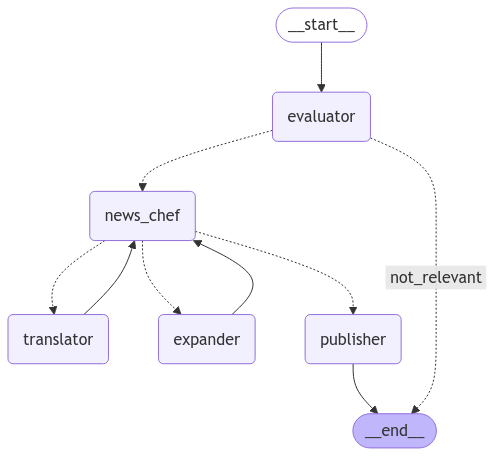

In [16]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except:
    pass

In [17]:
initial_state = {"article_state": "The Pope will visit Spain today"}
result = app.invoke(initial_state)

print("Final result:", result)

get_transfer_news_grade: Current state: {'article_state': 'The Pope will visit Spain today'}
Evaluator: Reading article but doing nothing to change it...
evaluator_router: Current state: {'article_state': 'The Pope will visit Spain today'}
Evaluator result:  binary_score='no'
Final result: {'article_state': 'The Pope will visit Spain today'}


In [18]:
initial_state = {"article_state": "Messi gonna switch from barca to real madrid"}
result = app.invoke(initial_state)

print("Final result:", result)

get_transfer_news_grade: Current state: {'article_state': 'Messi gonna switch from barca to real madrid'}
Evaluator: Reading article but doing nothing to change it...
evaluator_router: Current state: {'article_state': 'Messi gonna switch from barca to real madrid'}
Evaluator result:  binary_score='yes'
evaluate_article: Current state: {'article_state': 'Messi gonna switch from barca to real madrid'}
News : Reading article but doing nothing to change it...
news_chef_router: Current state: {'article_state': 'Messi gonna switch from barca to real madrid'}
News chef result:  can_be_posted='no' meets_word_count='no' is_sensationalistic='yes' is_language_german='no'
translate_article: Current state: {'article_state': 'Messi gonna switch from barca to real madrid'}
evaluate_article: Current state: {'article_state': "Here's the translation:\n\nMessi wird von Barça zu Real Madrid wechseln.\n\n(Note: I've tried to maintain a neutral tone, as the original text is quite brief and doesn't express a

In [19]:
initial_state = {"article_state": "Messi wird von Barça zu Real Madrid wechseln"}
result = app.invoke(initial_state)

print("Final result:", result)

get_transfer_news_grade: Current state: {'article_state': 'Messi wird von Barça zu Real Madrid wechseln'}
Evaluator: Reading article but doing nothing to change it...
evaluator_router: Current state: {'article_state': 'Messi wird von Barça zu Real Madrid wechseln'}
Evaluator result:  binary_score='yes'
evaluate_article: Current state: {'article_state': 'Messi wird von Barça zu Real Madrid wechseln'}
News : Reading article but doing nothing to change it...
news_chef_router: Current state: {'article_state': 'Messi wird von Barça zu Real Madrid wechseln'}
News chef result:  can_be_posted='no' meets_word_count='no' is_sensationalistic='yes' is_language_german='yes'
expand_article: Current state: {'article_state': 'Messi wird von Barça zu Real Madrid wechseln'}
evaluate_article: Current state: {'article_state': 'Der Transfermarkt ist in Bewegung und die Gerüchteküche brodelt. Laut verschiedenen Quellen soll Lionel Messi von FC Barcelona zu Real Madrid wechseln. Der argentinische Stürmer, de